<a href="https://colab.research.google.com/github/noahreed1/IT480-FA26/blob/main/Lab2_CNN_PetFinder_Starter1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *(Noah Reed and Jack Nelson)*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [4]:
# Clone the repo to access the data (only needs to run once per Colab session)
!git clone https://github.com/noahreed1/IT480-FA26.git

Cloning into 'IT480-FA26'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 92 (delta 5), reused 3 (delta 3), pack-reused 66 (from 1)
Receiving objects: 100% (92/92), 807.96 KiB | 3.48 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [5]:
# Your imports here
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical




---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [6]:
# Write your image-loading function here



In [7]:
# Build X and y, then split into train/test here


(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [8]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu')) # Example dense layer
model.add(Dense(10, activation='softmax')) # Output layer for 10 classes

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile your model here

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [10]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.8589 - loss: 0.3954 - val_accuracy: 0.8889 - val_loss: 0.3122
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9046 - loss: 0.2679 - val_accuracy: 0.8980 - val_loss: 0.2769
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9184 - loss: 0.2232 - val_accuracy: 0.9072 - val_loss: 0.2562
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9296 - loss: 0.1925 - val_accuracy: 0.9103 - val_loss: 0.2510
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9398 - loss: 0.1639 - val_accuracy: 0.9134 - val_loss: 0.2444
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9469 - loss: 0.1413 - val_accuracy: 0.9164 - val_loss: 0.2449
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9565 - loss: 0.1194 - val_accuracy: 0.9057 - val_loss: 0.2912
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9625 -

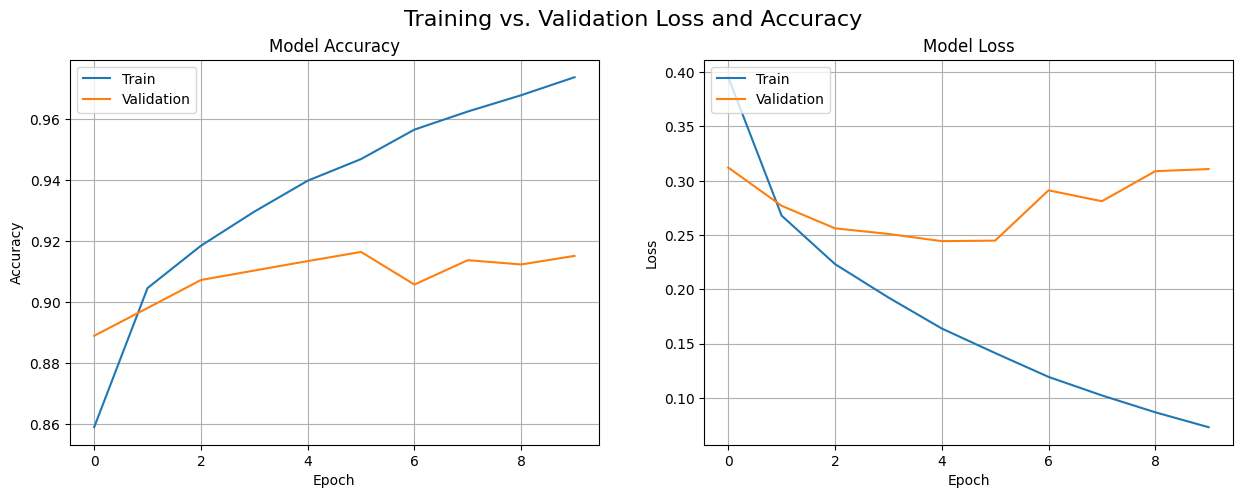

In [11]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy values
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')
    ax1.grid(True)

    # Plot training & validation loss values
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')
    ax2.grid(True)

    fig.suptitle(title, fontsize=16)
    plt.show()

plot_history(history, "Training vs. Validation Loss and Accuracy")

*Your fit diagnosis, with specific evidence from your curve:*

The model fits well through epochs 4 to 5, then starts overfitting. Validation loss drops from about 0.31 to a minimum of about 0.24 at epochs 4 and 5, and validation accuracy rises from about 0.89 to a peak of about 0.917 at epoch 5. After that, training loss keeps falling to about 0.07 and training accuracy climbs to about 0.97. Validation loss climbs back to about 0.31 and validation accuracy plateaus around 0.91 to 0.915, so the widening gap means the best weights are at epoch 4 or 5, which early stopping on val_loss would capture.




In [12]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.3108
Test Accuracy: 0.9151


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

We chose to add dropout and early stopping because our model was overfitting.

*Which path are you taking, and why:*




In [21]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
# Build your improved model here
model_new = Sequential()
model_new.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model_new.add(MaxPooling2D(pool_size=(2, 2)))
model_new.add(Dropout(0.25))
model_new.add(Flatten())
model_new.add(Dense(128, activation='relu')) # Example dense layer
model_new.add(Dropout(0.5))
model_new.add(Dense(10, activation='softmax')) # Output layer for 10 classes

model_new.summary()

model_new.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Train your improved model here
history = model_new.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    epochs=15,
                    batch_size=64,
                    callbacks=[early_stop])

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 37ms/step - accuracy: 0.8170 - loss: 0.5202 - val_accuracy: 0.8757 - val_loss: 0.3469
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.8692 - loss: 0.3647 - val_accuracy: 0.8883 - val_loss: 0.3103
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.8818 - loss: 0.3251 - val_accuracy: 0.8934 - val_loss: 0.2890
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.8915 - loss: 0.3016 - val_accuracy: 0.8996 - val_loss: 0.2743
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.8976 - loss: 0.2828 - val_accuracy: 0.8971 - val_loss: 0.2798
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - accuracy: 0.9005 - loss: 0.2711 - val_accuracy: 0.9087 - val_loss: 0.2547
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.9053 - loss: 0.2593 - val_accuracy: 0.9076 - val_loss: 0.2571
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9068 - loss: 0.2507 - 

--- ## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | 0.9151 | 0.9132 |
| Fit pattern (good/over/under) | Overfitting | Good fit (Less Overfitting) |
| What changed | - | Dropout, Early Stopping |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

Test loss: 0.2404
Test accuracy: 0.9132
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


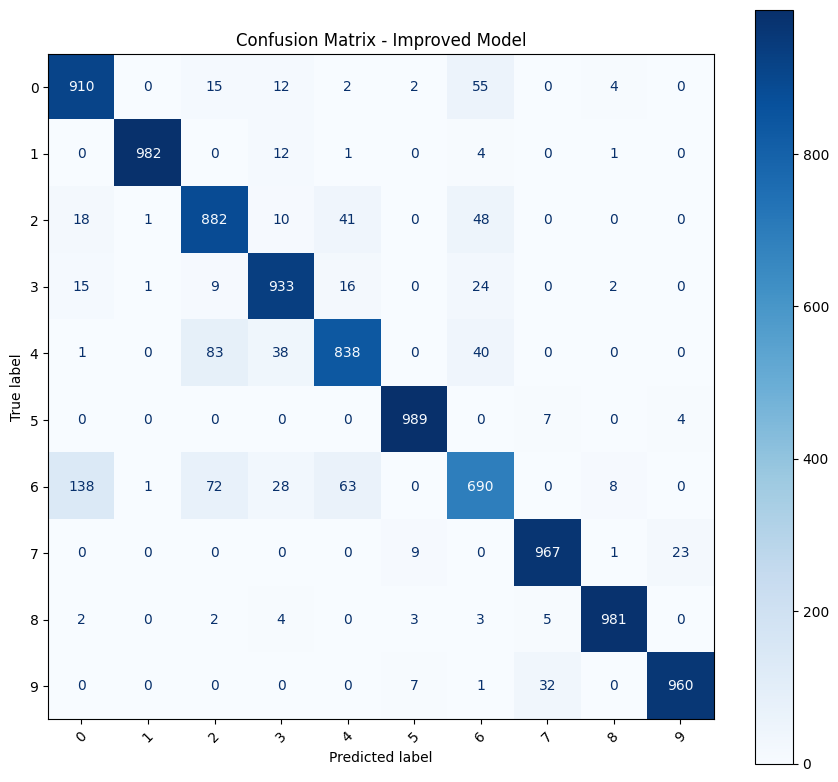

              precision    recall  f1-score   support

           0     0.8395    0.9100    0.8733      1000
           1     0.9970    0.9820    0.9894      1000
           2     0.8297    0.8820    0.8551      1000
           3     0.8997    0.9330    0.9161      1000
           4     0.8720    0.8380    0.8547      1000
           5     0.9792    0.9890    0.9841      1000
           6     0.7977    0.6900    0.7399      1000
           7     0.9565    0.9670    0.9617      1000
           8     0.9840    0.9810    0.9825      1000
           9     0.9726    0.9600    0.9663      1000

    accuracy                         0.9132     10000
   macro avg     0.9128    0.9132    0.9123     10000
weighted avg     0.9128    0.9132    0.9123     10000



In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Evaluate your improved model and build a confusion matrix here
test_loss, test_acc = model_new.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Get predictions for the confusion matrix and classification report
y_pred_probs = model_new.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

class_names = [str(i) for i in range(10)]  # replace with real names if you have them

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix - Improved Model")
plt.tight_layout()
plt.show()

# 4. Per-class precision, recall, F1
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

*Your discussion of the confusion matrix:*

The confusion matrix for the improved model achieves a test accuracy of 91%, and it correctly identifies most classes however class 6 it struggled the most on.


---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

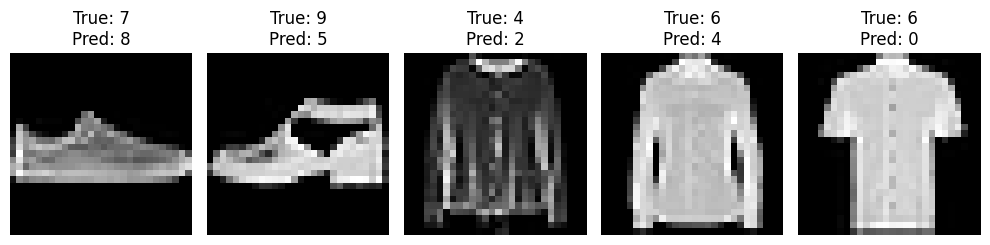

In [26]:
import matplotlib.pyplot as plt

# Find indices of misclassified images
misclassified_indices = np.where(y_true != y_pred)[0]

# Select a few (e.g., 5) misclassified images to display
num_to_display = 5
display_indices = misclassified_indices[:num_to_display]

plt.figure(figsize=(10, 5))
for i, index in enumerate(display_indices):
    plt.subplot(1, num_to_display, i + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_true[index]}\nPred: {y_pred[index]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


*Your observations about the misclassified images:*


My observations of this class images, is that all of the images are very poor quality and high pixelated. This is most likely causing the issue of these images being poorly classified.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.